In [1]:
print("om")

om


In [2]:
import os
import sys

In [3]:
# ============================================================
# Setup Project Path
# ============================================================

project_root = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..")
)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project Root:", project_root)

Project Root: c:\Users\akash\OneDrive\Documents\Qclarvoyance resources\Quantum_Protein_Ligand_Docking


In [4]:
import pickle
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile
from src.quantum.grover import GroverBuilder
from src.quantum.state_preparation import StatePreparationBuilder

In [5]:
with open("../../outputs/project_data.pkl", "rb") as f:
    project_data = pickle.load(f)

In [6]:
iteration = 1

amp_data = project_data.amplitude_vectors[iteration]

In [7]:
target = ""

for bits in project_data.encoded_ligand["Encoded"]:
    target += f"{bits[0]}{bits[1]}"

print(target)

111101


In [8]:
builder = GroverBuilder()

grover = builder.build(amplitude_data=amp_data,target_state=target,iterations=1)

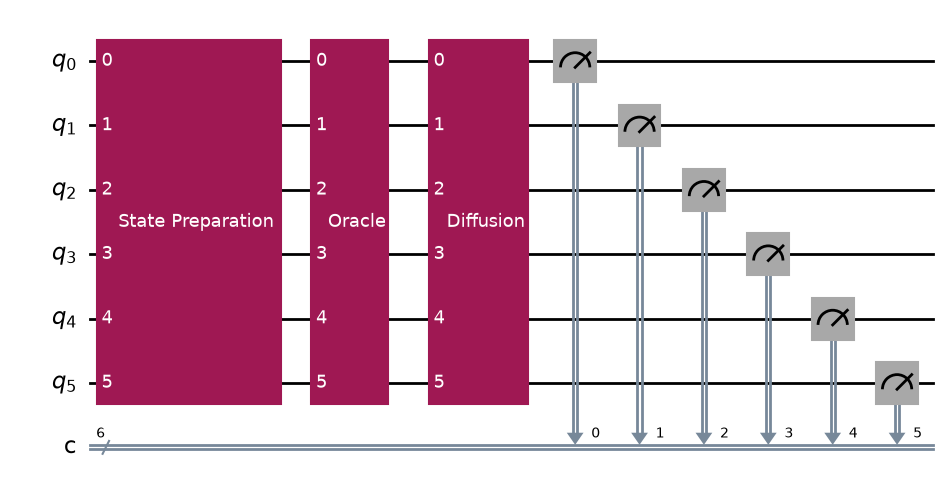

In [9]:
grover.draw("mpl")

In [10]:
# Us = StatePreparationBuilder().prepare(amp_data)

backend = AerSimulator()

compiled = transpile(grover,backend,optimization_level=1)

result = backend.run(compiled).result()

In [11]:
compiled.depth()

119

In [12]:
# compiled.draw("mpl")

In [13]:
counts = result.get_counts()

In [14]:
counts

{'111101': 759,
 '001100': 30,
 '000001': 31,
 '010000': 38,
 '101001': 33,
 '110010': 37,
 '001011': 35,
 '011100': 28,
 '110011': 33}

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [16]:
# Save the account for the first time. Comment out if account is already saved.
QiskitRuntimeService.save_account(channel="ibm_quantum_platform",
                                  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/752e715c5ece4d4eb056d138831cfae9:ab616613-4c94-406b-8698-ff7922ea54f2::",
                                  token="fBiJzlm4dpNzt08zilBN16hDWHE8w7_jPVvbuqKLjiDB",overwrite=True)

In [17]:
#Get the runtimeService to do the operations in cloud.
service = QiskitRuntimeService()

In [18]:
#Install the required primitive.
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_kingston")
print(backend.name)

ibm_marrakesh


In [19]:
## Transpile to Instruction Set Architecture (ISA) circuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(grover)

# display(qc_isa.draw("mpl"))



In [20]:
qc_isa.depth()

11660

In [21]:
## Execute on real hardware:
sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs, shots=1000)


In [22]:
res = job.result()
counts = res[0].data.c.get_counts()

In [25]:
counts["111101"]

5

In [23]:
counts

{'101011': 13,
 '101110': 6,
 '000110': 28,
 '001100': 34,
 '001111': 25,
 '000010': 31,
 '010001': 23,
 '101111': 10,
 '011011': 28,
 '000011': 30,
 '110010': 3,
 '011101': 26,
 '111111': 5,
 '001110': 26,
 '001011': 31,
 '000001': 27,
 '001010': 41,
 '001101': 24,
 '000100': 24,
 '011000': 23,
 '010111': 16,
 '101010': 10,
 '010010': 23,
 '010101': 30,
 '111011': 4,
 '011110': 24,
 '110101': 8,
 '000101': 35,
 '110001': 5,
 '110111': 7,
 '000000': 22,
 '011100': 28,
 '100011': 3,
 '100111': 5,
 '001000': 31,
 '111101': 5,
 '101001': 10,
 '011111': 18,
 '101101': 8,
 '011010': 24,
 '110000': 4,
 '010011': 25,
 '011001': 21,
 '110011': 5,
 '001001': 22,
 '100000': 10,
 '100110': 5,
 '000111': 19,
 '111001': 7,
 '100001': 4,
 '010100': 16,
 '111110': 6,
 '010110': 13,
 '010000': 17,
 '100101': 5,
 '100100': 7,
 '101100': 7,
 '100010': 6,
 '110100': 6,
 '111010': 6,
 '101000': 4,
 '111100': 4,
 '111000': 2,
 '110110': 5}

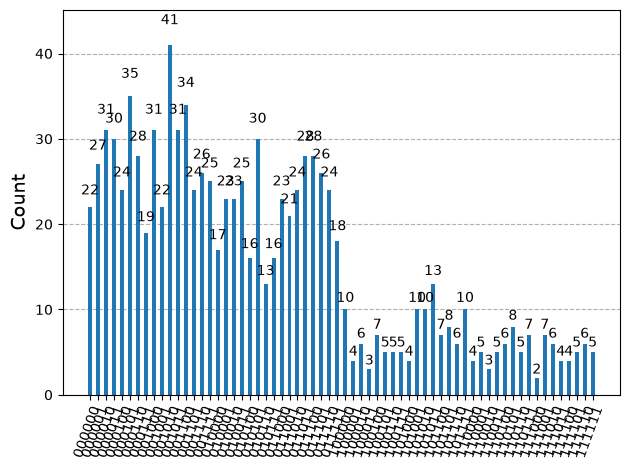

In [24]:
## Analysis
from qiskit.visualization import plot_histogram
plot_histogram(counts)